# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 11: Iterative Linear Solvers

### Professor: Dane Taylor
### Date: Spring 2024


In [1]:
%pylab inline
import timeit
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Residual Correction

In [30]:
A0 = array([[2,1,0],
          [1,2,1],
          [0,1,2]],dtype=float)
B = array([[0,1,1],
          [-1,0,1],
          [-1,-1,0]],dtype=float)
C = inv(A0)
eps = .9

print(A0,'\n\n',B,'\n\n',A0 + eps*B,'\n\n')
print(C,'\n\n',inv(A0+eps*B),'\n\n')

[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]] 

 [[ 0.  1.  1.]
 [-1.  0.  1.]
 [-1. -1.  0.]] 

 [[ 2.   1.9  0.9]
 [ 0.1  2.   1.9]
 [-0.9  0.1  2. ]] 


[[ 0.75 -0.5   0.25]
 [-0.5   1.   -0.5 ]
 [ 0.25 -0.5   0.75]] 

 [[ 0.67793594 -0.66014235  0.32206406]
 [-0.33985765  0.85587189 -0.66014235]
 [ 0.32206406 -0.33985765  0.67793594]] 




In [31]:
b = array([3,6,-2],dtype=float)
true_x = linalg.solve(A0+eps*B,b)
true_x

array([-2.57117438,  5.43594306, -2.42882562])

In [32]:
# now implement residual correction method
xt = ones(len(b))
T = 12
error = zeros(T)
for t in range(T):
    print(xt)
    r = b - dot(A0+eps*B, xt) # the residual
    xt = xt + dot(C,r) # correct x estimate
    error[t] = norm(true_x-xt,2) # keep track of errors

[1. 1. 1.]
[-2.15  5.5  -2.85]
[-2.6    5.815 -2.4  ]
[-2.74175  5.41    -2.25825]
[-2.5595    5.282425 -2.4405  ]
[-2.50209125  5.44645    -2.49790875]
[-2.5759025   5.49811787 -2.4240975 ]
[-2.59915304  5.43168775 -2.40084696]
[-2.56925949  5.41076226 -2.43074051]
[-2.55984302  5.43766646 -2.44015698]
[-2.57194991  5.44614128 -2.42805009]
[-2.57576358  5.43524508 -2.42423642]


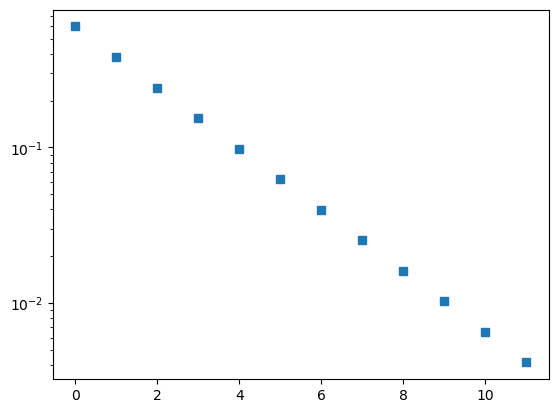

In [33]:
semilogy(error,'s ');

In [34]:
print('convergence rates estimates')
#print(error[9]/error[8])
print(error[1:]/error[:-1])

convergence rates estimates
[0.6363961 0.6363961 0.6363961 0.6363961 0.6363961 0.6363961 0.6363961
 0.6363961 0.6363961 0.6363961 0.6363961]


In [35]:
norm(C@B,1)*eps

0.9000000000000002

## 2. Gauss Jacobi Iteration

In [48]:
def Gauss_Jacobi(A, # input matrix
                 x0,# initial condition
                 b, # b vector
                 T): # number of iteration
    
    true_x =  linalg.solve(A,b)

    X = zeros((T,len(b))) # matrix saves all of the x values for diferent t
    X[0] = x0 # initial condition
    e = zeros(T) # error at each time t
    
    for t in range(T-1):
        e[t] = norm( true_x - X[t],inf)  # error e at step t
        for i in range(len(b)):
            sum_part = 0
            for j in range(len(A)):
                 if j!=i:
                         sum_part += A[i,j]*X[t,j] 
                        
            X[t+1,i] = (b[i] - sum_part ) / A[i,i]
            
        print(X[t+1])
    return X,e

In [49]:
A = array([[10,2,1],
          [2,9,-1],
          [3,-2,-6]],dtype=float)

b = array([3,6,9],dtype=float)

print(A,'\n\n',b)
print('\n',linalg.solve(A,b))

[[10.  2.  1.]
 [ 2.  9. -1.]
 [ 3. -2. -6.]] 

 [3. 6. 9.]

 [ 0.36125654  0.42408377 -1.46073298]


In [50]:
T = 30
x0 = linspace(0,5,3)
X,e = Gauss_Jacobi(A,x0,b,T)

[-0.7         1.22222222 -2.33333333]
[ 0.28888889  0.56296296 -2.25740741]
[ 0.41314815  0.35164609 -1.54320988]
[ 0.38399177  0.4033882  -1.41064129]
[ 0.36038649  0.42459724 -1.44246685]
[ 0.35932724  0.42630669 -1.46133917]
[ 0.36087258  0.42444515 -1.46243861]
[ 0.36135483  0.42397958 -1.46104543]
[ 0.36130863  0.42402721 -1.46064911]
[ 0.36125947  0.42408152 -1.46068809]
[ 0.36125251  0.42408811 -1.46073077]
[ 0.36125546  0.42408491 -1.46073645]
[ 0.36125666  0.42408363 -1.46073391]
[ 0.36125667  0.42408364 -1.46073288]
[ 0.36125656  0.42408375 -1.46073288]
[ 0.36125654  0.42408378 -1.46073297]
[ 0.36125654  0.42408377 -1.46073299]
[ 0.36125654  0.42408377 -1.46073299]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654  0.42408377 -1.46073298]
[ 0.36125654

Text(0.5, 0, 'iteration, $t$')

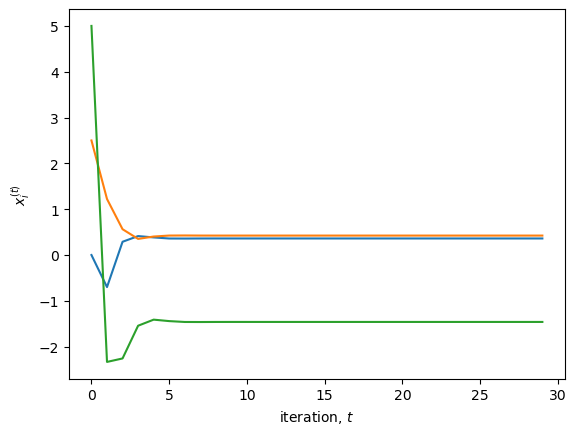

In [51]:
plot(X);
ylabel('$x_i^{(t)}$')
xlabel('iteration, $t$')

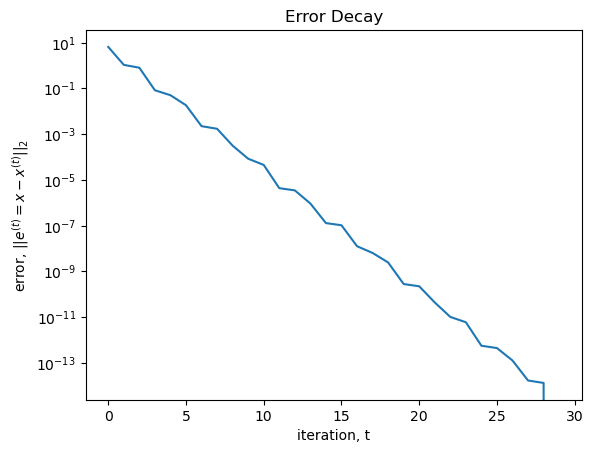

In [52]:
def make_error_plot(e):
    semilogy(e);
    title('Error Decay');
    xlabel('iteration, t');
    ylabel('error, $||e^{(t)}=x-x^{(t)}||_2$');

make_error_plot(e)

In [53]:
np.mean((e[1:]/e[:-1]))

0.3793119690382562

#### Matrix-based definition of Gauss-Jacobi

In [54]:
def Gauss_Jacobi_2(A, # input matrix
                 b, # b vector
                 tol=10**(-15)): # number of iteration
    
    N = diag(diag(A)) # diagonal entries in A
    Ninv = diag( diag(A)**(-1) )
    P = A - N    
    x = random.rand(len(A))
    e = 1
    while e>tol:
        x_old = x
        x = (Ninv) @ (b - P@x) # x=F(x) step
        e = norm(x_old-x)  # error e at step t        
    return x 

In [56]:
x = Gauss_Jacobi_2(A,b)
x

array([ 0.36125654,  0.42408377, -1.46073298])

# 3. Sparse Matrix Computations

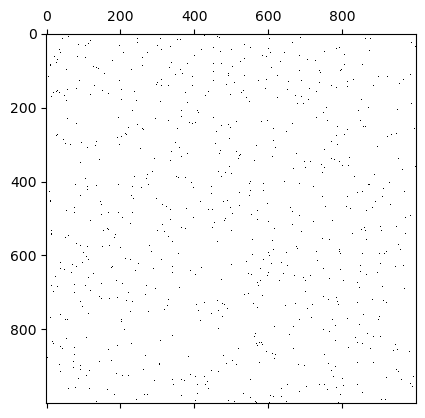

In [39]:
# Study a matrix in which each row/rol contains approximately 5 ones and 995 zeros.
n = 1000
p = 5/n
A = random.rand(n,n)<p
spy(A);# dots show where the nonzeros are

In [40]:
x = random.rand(n) 
def matrix_vector_mult(A,x):
    return A@x

b = matrix_vector_mult(csr_matrix(A),x)

In [41]:
TRIALS = 100
runtime = timeit.timeit('matrix_vector_mult(A,x)', globals=globals(),  number=TRIALS)/TRIALS
runtime

0.0019443387491628527

In [42]:
ns = array(logspace(2,4.4,4),dtype=int)
ns

array([  100,   630,  3981, 25118])

In [43]:
runtimes = zeros(len(ns))
runtimes2 = zeros(len(ns))
for i,n in enumerate(ns):
    A = random.rand(n,n)<p
    x = random.rand(n)
    TRIALS=2
    runtimes[i] = timeit.timeit('matrix_vector_mult(A,x)', globals=globals(),  number=TRIALS)/TRIALS
    A_sparse = csr_matrix(A)
    runtimes2[i] = timeit.timeit('matrix_vector_mult(A_sparse,x)', globals=globals(),  number=TRIALS)/TRIALS    

Text(0, 0.5, 'runtime in seconds')

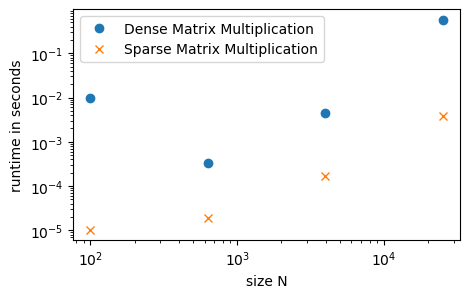

In [44]:
fig2, ax = subplots(1,1, figsize=(5,3))
loglog(ns,runtimes,'o ')
loglog(ns,runtimes2,'x ')
legend(['Dense Matrix Multiplication','Sparse Matrix Multiplication'])
xlabel('size N')
ylabel('runtime in seconds')

#### Sparse matrix multiplication is 10-100 times faster